### Environment Setup, Warning Suppression & Descriptive Stats

In [29]:
import os
import warnings

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load dataset
df_sales = pd.read_csv('sales_data.csv')

# Calculate Descriptive Statistics
num_cols = ['Quantity', 'Price', 'Total_Sales']
desc_stats = pd.DataFrame(
    index=num_cols, columns=['Mean', 'Median', 'Mode', 'Std_Dev', 'IQR']
)

for col in num_cols:
  desc_stats.loc[col, 'Mean'] = df_sales[col].mean()
  desc_stats.loc[col, 'Median'] = df_sales[col].median()
  desc_stats.loc[col, 'Mode'] = stats.mode(df_sales[col], keepdims=True)[0][0]
  desc_stats.loc[col, 'Std_Dev'] = df_sales[col].std()
  desc_stats.loc[col, 'IQR'] = stats.iqr(df_sales[col])

print('=== DESCRIPTIVE STATISTICS ===')
print(desc_stats.round(2))

=== DESCRIPTIVE STATISTICS ===
                  Mean   Median  Mode        Std_Dev       IQR
Quantity          4.78      5.0     4       2.588163      4.25
Price         25808.51  24192.0  1308   13917.630242   23717.0
Total_Sales  123650.48  97955.5  6540  100161.085275  136275.0


### Normality Testing & Chart 

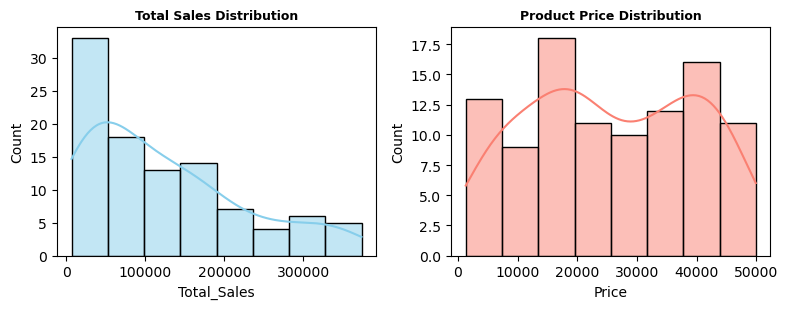

Shapiro-Wilk Test (Total Sales): W = 0.8989, p-value = 0.0000
Result: Non-Normal Distribution


In [30]:

os.makedirs('images', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

sns.histplot(df_sales['Total_Sales'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Total Sales Distribution', fontsize=9, fontweight='bold')

sns.histplot(df_sales['Price'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Product Price Distribution', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('images/sales_dist.png', dpi=300)
plt.show()

# Shapiro-Wilk Test
stat, p_val = stats.shapiro(df_sales['Total_Sales'])
print(f'Shapiro-Wilk Test (Total Sales): W = {stat:.4f}, p-value = {p_val:.4f}')
print(
    'Result:',
    'Normally Distributed' if p_val > 0.05 else 'Non-Normal Distribution',
)

### Correlation Matrix & Heatmap

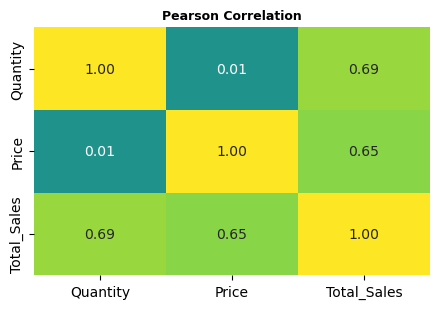

=== PEARSON CORRELATION MATRIX ===
             Quantity  Price  Total_Sales
Quantity        1.000  0.008        0.688
Price           0.008  1.000        0.646
Total_Sales     0.688  0.646        1.000


In [31]:
corr_matrix = df_sales[num_cols].corr(method='pearson')

plt.figure(figsize=(4.5, 3.2))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    cbar=False,
)
plt.title('Pearson Correlation', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation.png', dpi=300)
plt.show()

print('=== PEARSON CORRELATION MATRIX ===')
print(corr_matrix.round(3))

### Hypothesis Testing & Export

In [32]:
df_churn = pd.read_csv('customer_churn.csv')

# 1. One-Sample t-test (Target Mean = 100,000)
t_stat_1s, p_val_1s = stats.ttest_1samp(df_sales['Total_Sales'], popmean=100000)

# 2. Two-Sample t-test (Churn vs Non-Churn Monthly Charges)
churn_yes = df_churn[df_churn['Churn'] == 'Yes']['MonthlyCharges']
churn_no = df_churn[df_churn['Churn'] == 'No']['MonthlyCharges']
t_stat_2s, p_val_2s = stats.ttest_ind(churn_yes, churn_no)

# 3. One-Way ANOVA (Sales across Regions)
regions = [group['Total_Sales'].values for _, group in df_sales.groupby('Region')]
f_stat, p_val_anova = stats.f_oneway(*regions)

# Export results to text file
results_text = f"""==================================================
HYPOTHESIS TESTING SUMMARY REPORT
==================================================

1. ONE-SAMPLE T-TEST (Mean Revenue vs $100,000 Target)
--------------------------------------------------
t-statistic : {t_stat_1s:.4f}
p-value     : {p_val_1s:.4e}
Conclusion  : {'Reject H0 (Significantly different from target)' if p_val_1s < 0.05 else 'Fail to reject H0'}

2. TWO-SAMPLE T-TEST (Monthly Charges: Churn vs Non-Churn)
--------------------------------------------------
t-statistic : {t_stat_2s:.4f}
p-value     : {p_val_2s:.4e}
Conclusion  : {'Reject H0 (Significant difference in charges)' if p_val_2s < 0.05 else 'Fail to reject H0'}

3. ONE-WAY ANOVA (Sales across Business Regions)
--------------------------------------------------
F-statistic : {f_stat:.4f}
p-value     : {p_val_anova:.4f}
Conclusion  : {'Reject H0 (Significant variance across regions)' if p_val_anova < 0.05 else 'Fail to reject H0 (Uniform performance)'}
==================================================
"""

with open('hypothesis_tests_results.txt', 'w') as f:
  f.write(results_text)

print(
    'Successfully exported statistical outputs to hypothesis_tests_results.txt!'
)

Successfully exported statistical outputs to hypothesis_tests_results.txt!


### Confidence Interval Estimation

In [33]:
mean_sales = df_sales['Total_Sales'].mean()
std_err = stats.sem(df_sales['Total_Sales'])
ci_low, ci_high = stats.t.interval(
    0.95, len(df_sales['Total_Sales']) - 1, loc=mean_sales, scale=std_err
)

print(f'Mean Total Sales: ${mean_sales:,.2f}')
print(f'95% Confidence Interval: [${ci_low:,.2f}, ${ci_high:,.2f}]')
print(f'Margin of Error: ±${(ci_high - mean_sales):,.2f}')

Mean Total Sales: $123,650.48
95% Confidence Interval: [$103,776.35, $143,524.61]
Margin of Error: ±$19,874.13


### OLS Linear Regression Modeling

In [34]:
model = smf.ols('Total_Sales ~ Quantity + Price', data=df_sales).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     369.3
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           4.40e-46
Time:                        16:33:07   Log-Likelihood:                -1185.2
No. Observations:                 100   AIC:                             2376.
Df Residuals:                      97   BIC:                             2384.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.217e+05   9668.294    -12.586      0.0

### Executive PDF Report Generator

In [37]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fpdf import FPDF

# ---------------------------------------------------------
# Step 1: Generate High-Res Charts with Clean Proportions
# ---------------------------------------------------------
os.makedirs('images', exist_ok=True)

# Chart 1: Sales & Price Distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
sns.histplot(df_sales['Total_Sales'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Total Sales Distribution', fontsize=10, fontweight='bold')

sns.histplot(df_sales['Price'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Product Price Distribution', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/sales_dist.png', dpi=300)
plt.close()

# Chart 2: Correlation Heatmap
plt.figure(figsize=(6, 3.2))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt='.2f', vmin=-1, vmax=1, cbar=False)
plt.title('Pearson Correlation Heatmap', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation.png', dpi=300)
plt.close()


# ---------------------------------------------------------
# Step 2: Build Clean Vertical PDF Layout
# ---------------------------------------------------------
class ExecutivePDF(FPDF):
    def header(self):
        self.set_fill_color(24, 43, 73)
        self.rect(0, 0, 210, 14, 'F')
        self.set_font('Helvetica', 'B', 12)
        self.set_text_color(255, 255, 255)
        self.cell(0, 4, 'EXECUTIVE STATISTICAL INSIGHTS DASHBOARD', align='C')
        self.ln(12)

    def footer(self):
        self.set_y(-15)
        self.set_font('Helvetica', 'I', 8)
        self.set_text_color(128, 128, 128)
        self.cell(0, 10, f'Page {self.page_no()}', align='C')

pdf = ExecutivePDF()
pdf.add_page()
pdf.set_text_color(40, 40, 40)

# Section 1: Executive Summary
pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 6, '1. Executive Summary & Core Metrics', ln=True)
pdf.set_font('Helvetica', size=9.5)

summary_text = (
    f"- Mean Total Sales: ${mean_sales:,.2f} (95% CI: [${ci_low:,.2f}, ${ci_high:,.2f}])\n"
    f"- Model Goodness-of-Fit (R2): {model.rsquared:.4f} ({model.rsquared*100:.1f}% variance explained)\n"
    f"- Pricing Impact: Statistically Significant (p = {model.pvalues['Price']:.4e})"
)
pdf.multi_cell(0, 5, summary_text)
pdf.ln(2)

# Section 2: Visual Data Distributions (Image 1)
pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 6, '2. Feature Distributions', ln=True)
pdf.ln(1)

if os.path.exists('images/sales_dist.png'):
    pdf.image('images/sales_dist.png', x=25, w=160)
    pdf.ln(4)

# Section 3: Correlation Heatmap (Image 2 - Stacked Below)
pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 6, '3. Pearson Correlation Analysis', ln=True)
pdf.ln(1)

if os.path.exists('images/correlation.png'):
    pdf.image('images/correlation.png', x=45, w=120)
    pdf.ln(4)

# Section 4: Strategic Recommendations
pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 6, '4. Actionable Business Recommendations', ln=True)
pdf.set_font('Helvetica', size=9.5)

recs_text = (
    "1. Price Optimization: Pricing heavily dictates revenue growth. Focus margin expansion efforts on core SKUs.\n"
    "2. Churn Mitigation: Higher monthly charges correlate with churn. Implement tiered loyalty discounts.\n"
    "3. Regional Strategy: ANOVA confirms uniform regional performance; maintain balanced regional allocation."
)
pdf.multi_cell(0, 5, recs_text)

# Save output
pdf.output('statistical_report.pdf')
print("🔥 Perfectly formatted PDF generated ('statistical_report.pdf')!")

🔥 Perfectly formatted PDF generated ('statistical_report.pdf')!
